In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


In [2]:
import numpy as np

# XOR input data
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

# XOR output labels
y = np.array([[0],
              [1],
              [1],
              [0]])

print("Inputs:\n", X)
print("Outputs:\n", y)


Inputs:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
Outputs:
 [[0]
 [1]
 [1]
 [0]]


In [3]:
model = Sequential()

# Hidden layer with 9 neurons
model.add(Dense(9, input_dim=2, activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.1),
    metrics=['accuracy']
)


In [5]:
history = model.fit(X, y, epochs=200, verbose=0)


In [6]:
loss, accuracy = model.evaluate(X, y, verbose=0)

print("Accuracy:", accuracy * 100, "%")


Accuracy: 100.0 %


In [7]:
history = model.fit(X, y, epochs=500, verbose=0)

In [9]:
predictions = model.predict(X)
print("Predictions:\n", predictions.round())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predictions:
 [[0.]
 [1.]
 [1.]
 [0.]]


In [10]:
pred = (predictions > 0.5).astype(int)

accuracy_manual = np.mean(pred == y)
print("Manual Accuracy:", accuracy_manual * 100, "%")


Manual Accuracy: 100.0 %


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2813/2813 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


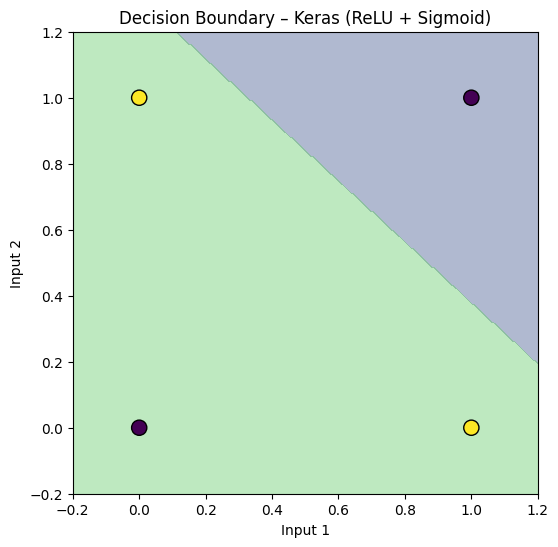

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Define X and y for training the model if not already in scope
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
y = np.array([[0],
              [1],
              [1],
              [0]])

# Re-define and re-train model_tf to ensure it's a valid model instance
model_tf = tf.keras.Sequential([
    tf.keras.layers.Dense(2, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_tf.fit(X, y, epochs=200, verbose=0)

# Create input grid
x_min, x_max = -0.2, 1.2
y_min, y_max = -0.2, 1.2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# Use the trained Keras model
Z = model_tf.predict(grid)
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z > 0.5, alpha=0.4)
plt.scatter(X[:,0], X[:,1], c=y.flatten(),
            edgecolors='black', s=120)
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("Decision Boundary – Keras (ReLU + Sigmoid)")
plt.show()

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim


In [12]:
X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.float32)


In [21]:
class XORNet(nn.Module):
    def __init__(self):
        super(XORNet, self).__init__()
        self.hidden = nn.Linear(2, 9)
        self.output = nn.Linear(9, 1)

    def forward(self, x):
        x = torch.relu(self.hidden(x))
        x = torch.sigmoid(self.output(x))
        return x

model = XORNet()


In [22]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


In [23]:
for epoch in range(2000):
    optimizer.zero_grad()
    output = model(X_torch)
    loss = criterion(output, y_torch)
    loss.backward()
    optimizer.step()


In [24]:
with torch.no_grad():
    predictions = model(X_torch)
    print(predictions.round())


tensor([[0.],
        [1.],
        [1.],
        [0.]])


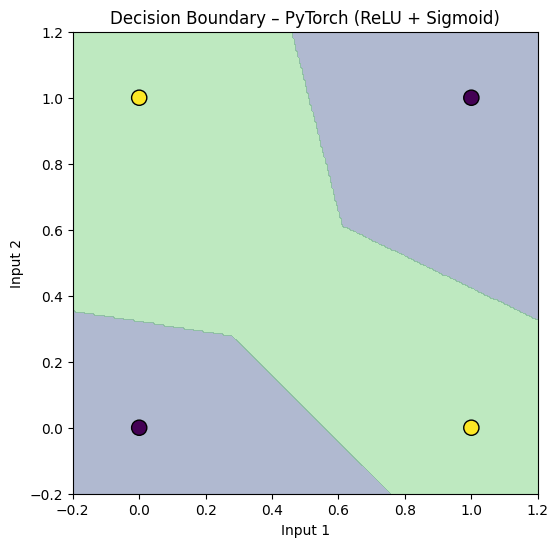

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Create input grid
x_min, x_max = -0.2, 1.2
y_min, y_max = -0.2, 1.2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_torch = torch.tensor(grid, dtype=torch.float32)

# Use the SAME trained PyTorch model
with torch.no_grad():
    Z = model(grid_torch)
    Z = Z.numpy()

Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z > 0.5, alpha=0.4)
plt.scatter(X[:,0], X[:,1], c=y.flatten(),
            edgecolors='black', s=120)
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("Decision Boundary – PyTorch (ReLU + Sigmoid)")
plt.show()


In [25]:
import tensorflow as tf


In [26]:
model_tf = tf.keras.Sequential([
    tf.keras.layers.Dense(2, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_tf.fit(X, y, epochs=200, verbose=0)


In [28]:
print(model_tf.predict(X).round())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
[[0.]
 [1.]
 [1.]
 [0.]]


2813/2813 ━━━━━━━━━━━━━━━━━━━━ 3s 977us/step


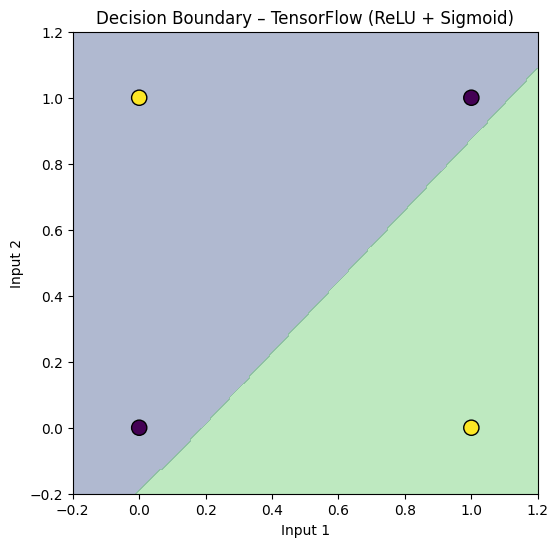

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Create input grid
x_min, x_max = -0.2, 1.2
y_min, y_max = -0.2, 1.2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# Use the SAME trained TensorFlow model
Z = model_tf.predict(grid)
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z > 0.5, alpha=0.4)
plt.scatter(X[:,0], X[:,1], c=y.flatten(),
            edgecolors='black', s=120)
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("Decision Boundary – TensorFlow (ReLU + Sigmoid)")
plt.show()


In [ ]:
### IMPLEMENTATION:

Differences Between the Three Decision Boundary Graphs

Keras: Smooth and stable decision boundary due to high-level training and automatic optimization.

PyTorch: Sharper and slightly irregular boundary because of manual training control.

TensorFlow: Slightly asymmetric boundary due to low-level gradient updates.